In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

print('Good imports')


Good imports


Text(0.5, 1.0, 'Визуализация дерева решений на датасете Iris')

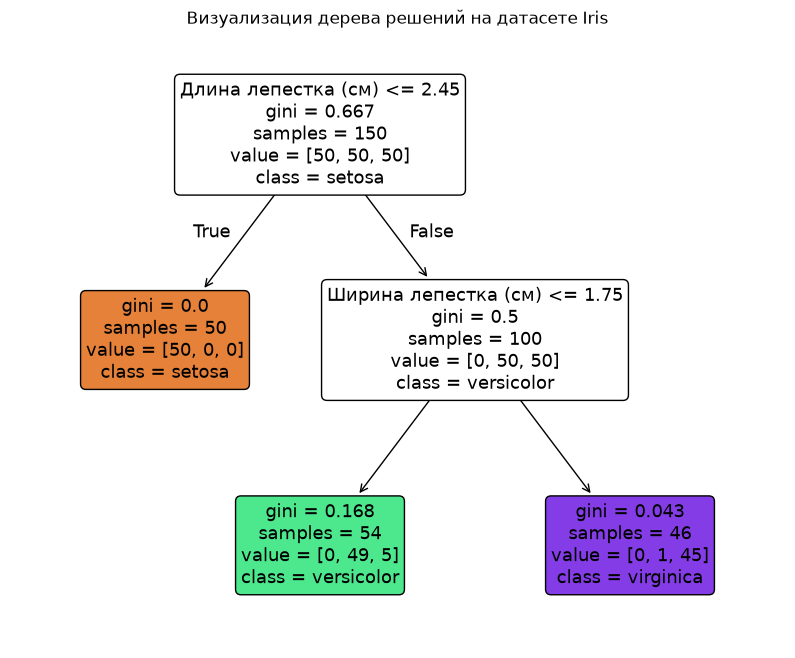

In [9]:
iris = load_iris()

X = iris.data[:, [2, 3]]
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X, y)

plt.figure(figsize=(10,8))
plot_tree(tree_clf,
        feature_names=['Длина лепестка (см)', 'Ширина лепестка (см)'],
        class_names=iris.target_names,
        filled = True,
        rounded=True)
plt.title('Визуализация дерева решений на датасете Iris')

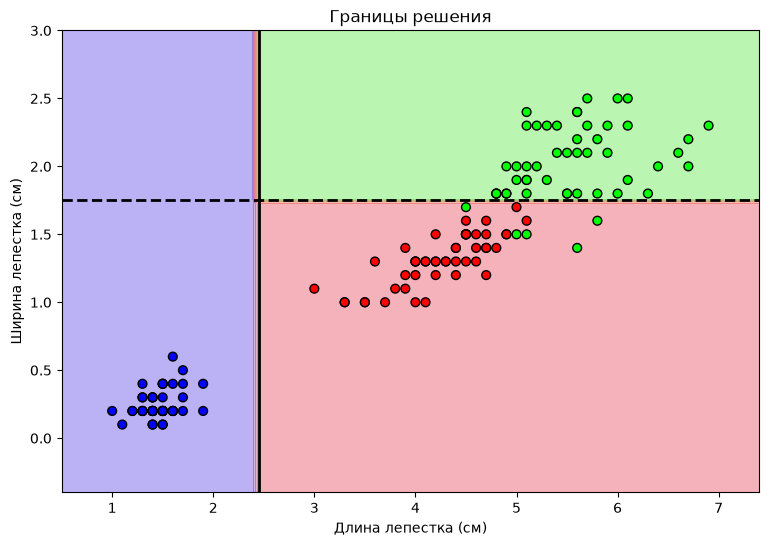

In [12]:
def plot_decision_boundary(clf, X, y):
    x1s = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)
    x2s = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap='brg')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg', edgecolor='k', s=40)
    plt.xlabel("Длина лепестка (см)")
    plt.ylabel("Ширина лепестка (см)")

plt.figure(figsize=(9, 6))
plot_decision_boundary(tree_clf, X, y)

plt.axvline(x=2.45, color='k', linestyle='-', linewidth=2)
plt.axhline(y=1.75, color='k', linestyle='--', linewidth=2)

plt.title("Границы решения")
plt.show()

In [14]:
# Создаем искусственный цветок
test_flower = [[5, 1.5]]
probabilities = tree_clf.predict_proba(test_flower) # точные вероятности для каждого вида
predicted_class = tree_clf.predict(test_flower)

print("--- Оценка вероятностей классов ---")
for i, name in enumerate(iris.target_names):
    print(f"Вероятность сорта {name.capitalize()}: {probabilities[0][i]:.2%}")

print(f"\nФинальный Класс: {iris.target_names[predicted_class][0].capitalize()}")


--- Оценка вероятностей классов ---
Вероятность сорта Setosa: 0.00%
Вероятность сорта Versicolor: 90.74%
Вероятность сорта Virginica: 9.26%

Финальный Класс: Versicolor


In [15]:
feature_importances = tree_clf.feature_importances_

print("--- Важность признаков по алгоритму CART ---")
for name, importance in zip(["Длина лепестка", "Ширина лепестка"], feature_importances):
    print(f"Признак '{name}': важность = {importance:.2%}")


--- Важность признаков по алгоритму CART ---
Признак 'Длина лепестка': важность = 56.20%
Признак 'Ширина лепестка': важность = 43.80%


In [16]:
large_test_data = np.random.rand(10000, 2) * 5

print("Измеряем скорость предсказания для 10 000 объектов:")
%timeit tree_clf.predict(large_test_data)

Измеряем скорость предсказания для 10 000 объектов:
906 μs ± 56.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


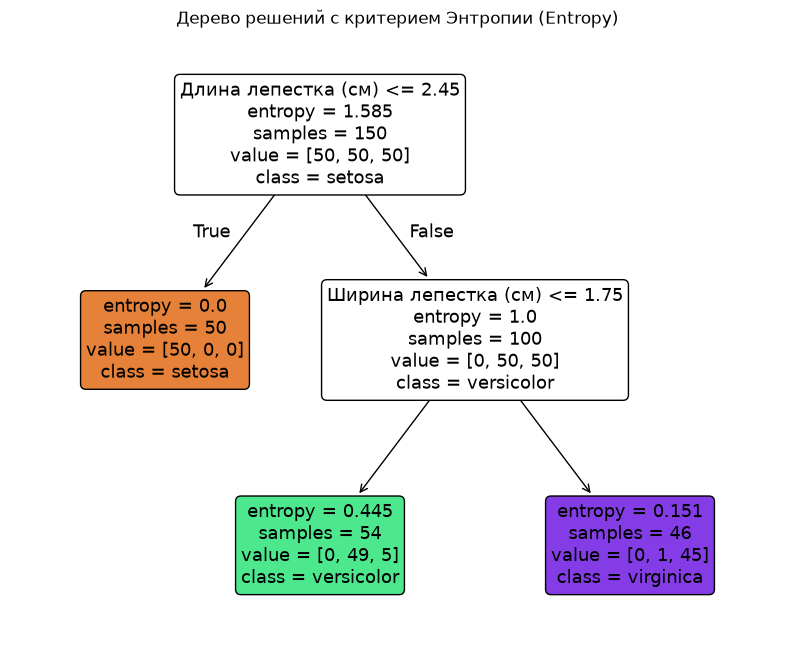

In [17]:
# Обучаем дерево с критерием Энтропии
entropy_tree_clf = DecisionTreeClassifier(max_depth=2, criterion="entropy", random_state=42)
entropy_tree_clf.fit(X, y)

plt.figure(figsize=(10, 8))
plot_tree(entropy_tree_clf, 
          feature_names=["Длина лепестка (см)", "Ширина лепестка (см)"], 
          class_names=iris.target_names, 
          filled=True, 
          rounded=True)
plt.title("Дерево решений с критерием Энтропии (Entropy)")
plt.show()
